# Connecting two LIF neurons with a delta synapse in MOOSE



---
# 1. The delta synapse

In the LIF model a spike is just an **event**. The simplest possible synapse turns that event into an **instantaneous jump** of the postsynaptic membrane potential:

> When a spike from presynatic neuron arrives at postsynaptic neuron (after a **delay**), the voltage of the postsynaptic neuron immediately changes by the synaptic **weight** $w$:
> $$V_m^{post} \;\rightarrow\; V_m^{pre} + w$$

After the jump nothing special happens at the synapse: $V_m$ simply **decays back towards rest** with the *membrane* time constant $\tau_m = R_m C_m$, exactly as in the LIF neuron. This is called a **delta synapse** because the input current is a delta function (infinitely brief).

* $w > 0$: the jump depolarizes the post neuron → **excitatory** (EPSP).
* $w < 0$: the jump hyperpolarizes the post neuron → **inhibitory** (IPSP).

### Delta synapse parameters in MOOSE

| Parameter | MOOSE field | Unit | What it controls |
|---|---|---|---|
| Weight | `synapse[0].weight` | **volts** | size of the voltage jump (sign = excitatory / inhibitory) |
| Delay | `synapse[0].delay` | seconds | time between the presynaptic spike and the jump |

In MOOSE the delta synapse is implemented as a **`SimpleSynHandler`** that receives the spike events and sends the (delayed, weighted) input straight to the LIF neuron's `activation` input.

---
# 2. Connecting two-neurons with a synapse

Neuron **A** (presynaptic) receives a steady current and fires repeatedly. Neuron **B** (postsynaptic) receives **no current at all**, so it can only fire through the synapse from A.

In [2]:
# If you need to install them, remove the '#' and run this line once:
# !pip install pymoose ipywidgets matplotlib numpy

import numpy as np                  # arrays and maths
import matplotlib.pyplot as plt     # plotting
from ipywidgets import interact, FloatSlider     # sliders
import moose                        # the simulator

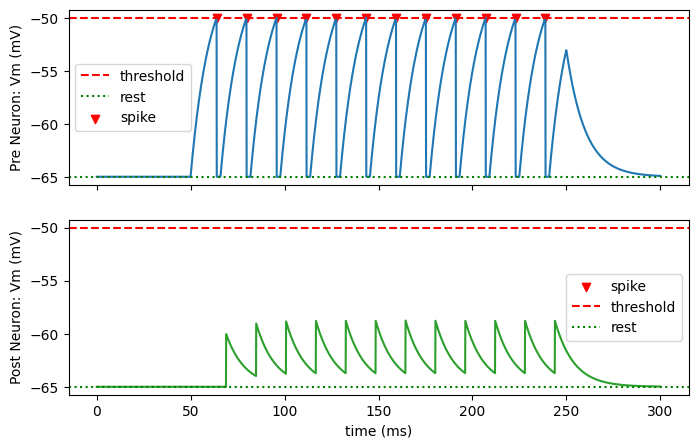

spikes of pre neuron: 12    spikes of post neuron: 0


In [42]:
# ---- 1. Clean up any old model, then make a fresh container ----------------
if moose.exists('/model'):
    moose.delete('/model')
moose.Neutral('/model')

# ---- 2. Create the two LIF neurons (identical, SI units) -------------------
pre = moose.LIF('/model/pre')       # neuron A: presynaptic
post = moose.LIF('/model/post')     # neuron B: postsynaptic

for neuron in (pre, post):          # give both neurons the same parameters
    neuron.Rm = 100e6               # 100 MOhm
    neuron.Cm = 100e-12             # 100 pF   (so tau_m = 10 ms)
    neuron.Em = -65e-3              # rest: -65 mV
    neuron.initVm = -65e-3
    neuron.thresh = -50e-3          # threshold: -50 mV
    neuron.vReset = -65e-3          # reset: -65 mV
    neuron.refractoryPeriod = 2e-3  # 2 ms

# ---- 3. Inject current into neuron A only (200 pA from 50 to 250 ms) -------
pulse = moose.PulseGen('/model/pulse')
pulse.delay[0] = 50e-3
pulse.width[0] = 200e-3
pulse.level[0] = 200e-12
moose.connect(pulse, 'output', pre, 'injectMsg')

# ---- 4. Build the DELTA synapse from A onto B ------------------------------
handler = moose.SimpleSynHandler('/model/post/handler')   # receives spikes
handler.synapse.num = 1                                   # one synapse
handler.synapse[0].weight = 5e-3                          # jump of 5 mV (in volts!)
handler.synapse[0].delay = 5e-3                           # arrives 5 ms after A's spike
moose.connect(pre, 'spikeOut', handler.synapse[0], 'addSpike')   # A's spikes -> synapse
moose.connect(handler, 'activationOut', post, 'activation')      # synapse -> B's voltage

# ---- 5. Record Vm of both neurons and the spike times of both --------------
pre_vm = moose.Table('/model/pre_vm')
moose.connect(pre_vm, 'requestOut', pre, 'getVm')
post_vm = moose.Table('/model/post_vm')
moose.connect(post_vm, 'requestOut', post, 'getVm')
pre_spikes = moose.Table('/model/pre_spikes')
moose.connect(pre, 'spikeOut', pre_spikes, 'input')       # table stores the spike times
post_spikes = moose.Table('/model/post_spikes')
moose.connect(post, 'spikeOut', post_spikes, 'input')

# ---- 6. Run ------------------------------------------------------------------
moose.reinit()
moose.start(0.3)                    # simulate 0.3 s

# ---- Plot ------------------------------------------------------------------
t = np.linspace(0, 0.3, len(pre_vm.vector))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax1.plot(t * 1000, np.array(pre_vm.vector) * 1000)
ax1.axhline(-50, color='red', ls='--', label='threshold')
ax1.axhline(-65, color='green', ls=':', label='rest')
ax1.scatter(pre_spikes.vector*1000, [-50]*len(pre_spikes.vector), marker="v", c="r", label="spike")
ax1.set_ylabel('Pre Neuron: Vm (mV)')
ax1.legend()
ax2.plot(t * 1000, np.array(post_vm.vector) * 1000, color='C2')
ax2.scatter(post_spikes.vector*1000, [-50]*len(post_spikes.vector), marker="v", c="r", label="spike")
ax2.axhline(-50, color='red', ls='--', label='threshold')
ax2.axhline(-65, color='green', ls=':', label='rest')
ax2.set_ylabel('Post Neuron: Vm (mV)')
ax2.set_xlabel('time (ms)')
ax2.legend()
plt.show()
print('spikes of pre neuron:', len(pre_spikes.vector), '   spikes of post neuron:', len(post_spikes.vector))

### 🧠 Question 1

Zoom in on one of B's voltage bumps. (a) What happens to $V_m$ of B at the moment the input arrives, and how large is the change? (b) What shape does the decay have, and which parameter sets how fast it decays? (c) How long after A's spike does this happen, and which parameter sets it? (d) Why does B not fire?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>🔎 Hint</summary>

Compare the *size of the jump* with the distance from rest (−65 mV) to threshold (−50 mV).

</details>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) $V_m$ of B makes an **instantaneous jump** (no rise time) of about **5 mV**, equal to the synaptic `weight`.

(b) After the jump it decays **exponentially back to rest** with the **membrane** time constant $\tau_m = R_mC_m = 10$ ms. In a delta synapse the synapse itself contributes no time course; all the timing comes from the neuron's membrane.

(c) **5 ms** after A's spike, set by `synapse[0].delay`.

(d) A single 5 mV jump is far from the 15 mV needed. Successive jumps do pile up, because B has not fully decayed before the next one arrives, but the sum only reaches about −59 mV, short of the −50 mV threshold.

</details>

---
# 3. Explore weight, delay and inhibition

The same script is wrapped in a function **`explore`**. The code inside is exactly what you just read, rearranged so the parameters are arguments (friendly units: mV, ms, pA, pF). You do not need to change it.

You only list the parameters you want to *change*; all the others keep the values in `DEFAULTS`.

In [43]:
# Default values (same as in the script above). Units: mV, ms, pA, pF
DEFAULTS = dict(weight=5, delay=5, pre_inject=200, post_inject=0, Cm_post=100)


def slider(start, lowest, highest, step):
    '''A slider that starts at `start` and moves between `lowest` and `highest`.'''
    return FloatSlider(value=start, min=lowest, max=highest, step=step, continuous_update=False)


def explore(**changes):
    '''Run the two-neuron network with the defaults, except for the parameters in `changes`.'''
    p = dict(DEFAULTS)            # start from the defaults ...
    p.update(changes)             # ... and replace the ones that were changed

    # ---- build the model (same steps as the script above) ----
    if moose.exists('/model'):
        moose.delete('/model')
    moose.Neutral('/model')

    pre = moose.LIF('/model/pre')
    post = moose.LIF('/model/post')
    for neuron in (pre, post):
        neuron.Rm = 100e6
        neuron.Cm = 100e-12
        neuron.Em = -65e-3
        neuron.initVm = -65e-3
        neuron.thresh = -50e-3
        neuron.vReset = -65e-3
        neuron.refractoryPeriod = 2e-3
    post.Cm = p['Cm_post'] * 1e-12                   # pF -> F  (Cm of B only)

    # current into A, and (optionally) into B
    for name, neuron, amount in (('pulse_pre', pre, p['pre_inject']),
                                 ('pulse_post', post, p['post_inject'])):
        pulse = moose.PulseGen('/model/' + name)
        pulse.delay[0] = 50e-3
        pulse.width[0] = 200e-3
        pulse.level[0] = amount * 1e-12              # pA -> A
        moose.connect(pulse, 'output', neuron, 'injectMsg')

    # the delta synapse from A onto B
    handler = moose.SimpleSynHandler('/model/post/handler')
    handler.synapse.num = 1
    handler.synapse[0].weight = p['weight'] * 1e-3   # mV -> V
    handler.synapse[0].delay = p['delay'] * 1e-3     # ms -> s
    moose.connect(pre, 'spikeOut', handler.synapse[0], 'addSpike')
    moose.connect(handler, 'activationOut', post, 'activation')

    # recording
    pre_vm = moose.Table('/model/pre_vm')
    moose.connect(pre_vm, 'requestOut', pre, 'getVm')
    post_vm = moose.Table('/model/post_vm')
    moose.connect(post_vm, 'requestOut', post, 'getVm')
    pre_spikes = moose.Table('/model/pre_spikes')
    moose.connect(pre, 'spikeOut', pre_spikes, 'input')
    post_spikes = moose.Table('/model/post_spikes')
    moose.connect(post, 'spikeOut', post_spikes, 'input')

    # ---- run ----
    moose.reinit()
    moose.start(0.3)

    # ---- plot ----
    t = np.linspace(0, 0.3, len(pre_vm.vector))
    va = np.array(pre_vm.vector) * 1000              # V -> mV
    vb = np.array(post_vm.vector) * 1000
    spikes_a = np.array(pre_spikes.vector)           # spike times (s)
    spikes_b = np.array(post_spikes.vector)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    ax1.plot(t * 1000, va)
    ax1.set_ylabel('A: Vm (mV)')
    ax1.plot(spikes_a * 1000, [-50] * len(spikes_a), 'rv', label='spike')
    ax1.axhline(-50, color='red', ls='--', label='threshold')
    ax1.axhline(-65, color='green', ls=':', label='rest')
    ax1.legend()
    ax2.plot(t * 1000, vb, color='C2')
    ax2.plot(spikes_b * 1000, [-50] * len(spikes_b), 'rv', label='spike')
    ax2.axhline(-50, color='red', ls='--', label='threshold')
    ax2.axhline(-65, color='green', ls=':', label='rest')
    # ax2.plot(spikes_b * 1000, [-50] * len(spikes_b), 'rv', label='spike of B')
    ax2.plot(spikes_a * 1000, [-66] * len(spikes_a), 'k|',
             label='pre spike')                  # when each jump is applied
    # ax2.set_ylim(-100, -40)
    ax2.set_ylabel('B: Vm (mV)')
    ax2.set_xlabel('time (ms)')
    ax2.legend(loc='upper right', ncol=4, fontsize=8)
    plt.show()

    # ---- numbers to help your predictions ----
    print(f'spikes of A: {len(spikes_a)}    spikes of B: {len(spikes_b)}')
    if len(spikes_b) == 0:
        print(f'highest Vm reached by B: {vb.max():.1f} mV   (threshold is -50 mV)')

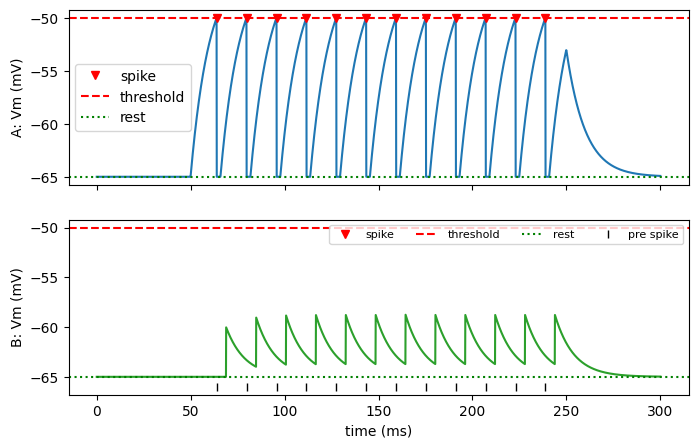

spikes of A: 12    spikes of B: 0
highest Vm reached by B: -58.8 mV   (threshold is -50 mV)


In [44]:
explore()

`interact(explore, weight=slider(5, 0, 15, 0.5))` means *"make a slider called `weight` that starts at 5, goes from 0 to 15 in steps of 0.5, and call `explore` with its value whenever you release it"*. Parameters that are not listed stay at their defaults.

### 3.1 Weight

In [39]:
interact(explore, weight=slider(5, 0, 15, 0.5));

interactive(children=(FloatSlider(value=5.0, continuous_update=False, description='weight', max=15.0, step=0.5…

### 🧠 Question 2

Increase `weight` from 0 to 15 mV. (a) How big is each jump compared with the `weight` slider? (b) Roughly at what `weight` does B start to fire, and why is this *less* than the 15 mV gap between rest and threshold? (c) 🟡 *Optional:* in the next cell, increase `Cm_post` (the capacitance of B) at `weight` = 8 mV and try `delay` too. What does each do?

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) Each jump is **exactly** the weight (5 mV for `weight` = 5), whatever the current voltage of B is. That is a defining property of a delta synapse.

(b) B starts to fire at about **12 mV**. It does not need a single jump of 15 mV because the jumps **sum**: the next input arrives before the previous one has decayed, so the peaks stack up to roughly 1.3 times the weight at this input rate. A threshold neuron *integrates* its inputs over time.

(c) Larger `Cm_post` means a larger $\tau_m$, so each jump **decays more slowly** and the inputs overlap more, so more summation: at `weight` = 8 mV B is silent at 100 pF but starts to fire at about 300 pF. `delay` only **shifts** B's response later in time; it does not change the jump size or how many times B fires.

</details>

In [40]:
# 🟡 Optional: capacitance of B and the synaptic delay
interact(explore, weight=slider(8, 0, 15, 0.5), Cm_post=slider(100, 50, 400, 50), delay=slider(5, 0, 30, 1));

interactive(children=(FloatSlider(value=8.0, continuous_update=False, description='weight', max=15.0, step=0.5…

### 3.2 Excitation and inhibition
There is no reversal potential in a delta synapse, so the **sign of the weight** decides everything. To see inhibition, B needs something to inhibit: here B also receives its own current of 160 pA, just above its rheobase (150 pA), so it fires about 6 times by itself.

In [41]:
interact(explore, weight=slider(0, -10, 10, 0.5), post_inject=slider(160, 0, 300, 10));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='weight', max=10.0, min=-10.…

### 🧠 Question 3

With `post_inject` = 160 pA: (a) how many spikes does B fire with `weight` = 0 (no synapse effect)? (b) What happens for `weight` = +4 mV and for −4 mV? (c) **Think:** name two things that a real synapse does that this delta synapse cannot.

> ✍️ **Your answer** *(double-click to type here, Shift+Enter to finish)*:
>
>

<details>
<summary>💡 Click to reveal the answer</summary>

(a) About **6 spikes** from its own current alone.

(b) `weight` = **+4 mV**: each input pushes B closer to threshold, so it fires **more** (about 12 spikes, roughly double). `weight` = **−4 mV**: each input knocks B back, so it is **silenced** (0 spikes). A negative weight is all it takes to make a delta synapse inhibitory.

(c) A delta synapse has: **no time course** (a real synaptic conductance rises and decays over milliseconds, set by `tau1` and `tau2` in a `SynChan`), and **no reversal potential** (a real synapse's effect depends on the membrane voltage, $I = g\,(E_\text{syn}-V_m)$, so its push gets weaker as $V_m$ approaches $E_\text{syn}$, and inhibition can be *shunting* even at rest). Related: it has no conductance, so it cannot change the membrane's effective resistance.

</details>

---
# 4. Summary

| Parameter | MOOSE field | Effect on the postsynaptic neuron |
|---|---|---|
| Weight (volts) | `synapse[0].weight` | size of the voltage jump; sign sets excitatory (+) or inhibitory (−) |
| Delay | `synapse[0].delay` | shifts the response in time only |
| Membrane $\tau_m = R_mC_m$ (a property of the *neuron*) | `Rm`, `Cm` | how long each jump lasts, so how strongly inputs sum |

**Delta vs. conductance-based (alpha/exponential) synapses**

| | Delta synapse (`SimpleSynHandler` → `activation`) | Conductance synapse (`SynChan`) |
|---|---|---|
| Effect of a spike | instant jump of $V_m$ | brief conductance change |
| Time course | only the membrane's $\tau_m$ | rise and decay (`tau1`, `tau2`) *plus* $\tau_m$ |
| Excitatory vs. inhibitory | sign of the weight | reversal potential `Ek` |
| Depends on $V_m$? | no | yes (driving force) |
| Parameters | weight, delay | `Gbar`, `Ek`, `tau1`, `tau2`, delay |
| Cost | cheapest | slightly more expensive |

**Take-home message:** a delta synapse is the simplest way to connect LIF neurons: a spike becomes an instantaneous voltage jump. It is fast and easy to reason about, ideal for large networks, but it leaves out the time course and voltage dependence of real synapses.